In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
chrun = pd.read_csv(url)

chrun.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [4]:
chrun = chrun[['tenure','age','address','income','ed','employ','equip','churn']]

chrun.head()

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0.0


In [6]:
x = np.asarray(chrun[['tenure','age','address','income','ed','employ','equip']])
y = np.asarray(chrun[['churn']])

print(x)

[[11. 33.  7. ...  5.  5.  0.]
 [33. 33. 12. ...  2.  0.  0.]
 [23. 30.  9. ...  1.  2.  0.]
 ...
 [ 6. 32. 10. ...  1. 10.  0.]
 [24. 30.  0. ...  4.  5.  0.]
 [61. 50. 16. ...  2. 22.  1.]]


In [8]:
xnorm = StandardScaler().fit(x).transform(x)

print(xnorm)

[[-1.13518441 -0.62595491 -0.4588971  ...  1.6961288  -0.58477841
  -0.85972695]
 [-0.11604313 -0.62595491  0.03454064 ... -0.6433592  -1.14437497
  -0.85972695]
 [-0.57928917 -0.85594447 -0.261522   ... -1.42318853 -0.92053635
  -0.85972695]
 ...
 [-1.36680743 -0.7026181  -0.16283445 ... -1.42318853 -0.02518185
  -0.85972695]
 [-0.53296457 -0.85594447 -1.14970993 ...  0.91629947 -0.58477841
  -0.85972695]
 [ 1.18104577  0.67731925  0.42929083 ... -0.6433592   1.31784991
   1.16316   ]]


In [9]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.33,random_state=42)


In [11]:
Lr = LogisticRegression().fit(xtrain,ytrain)

In [13]:
yhat = Lr.predict(xtest)

In [15]:
prob = Lr.predict_proba(xtest)

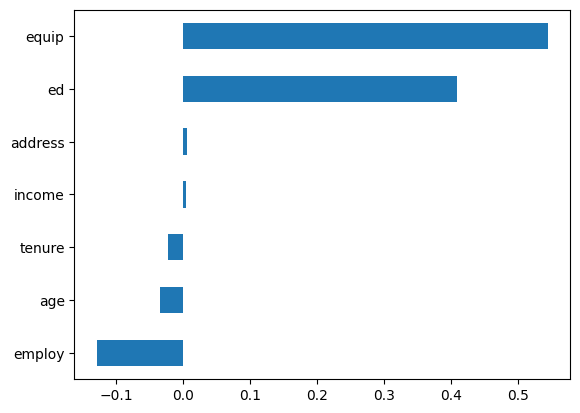

In [16]:
coefficients = pd.Series(Lr.coef_[0], index=chrun.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.show()

In [17]:
log_loss(ytest,prob)

0.6057650240214033